In this notebook, we will make some plots trying to show the different physical nature of ELG galaxies relative to BGS-B etc.


Notes: 
[OII] is typically strong in ELG
Ting-Wen Lan (10 mins) - The Diversity of ELG [OII] Line Profiles and its links to Star-formation and Morphology

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import pickle
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}


%load_ext autoreload
%autoreload 2


In [2]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [3]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [4]:
from mass_and_photo_corrections import DWARF_CATALOG_SPEC_HDU 

In [5]:
# from elg_explore import deredshift_for_stacking

In [6]:
# deredshift_for_stacking()

## Make the plot comparing ELG vs. non-ELG objects ... 

Halpha EW, balmer dust decrement, metallicity maybe?

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pickle

# Matches stack_mstar_elg_vs_noelg.py + run_stack_fastspec_elg_noelg.sh
STACK_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"
FASTSPEC_HDU = 3
LINE_FLUX_TYPE = "FLUX"   # matches stack_direct_metallicity.py default

# 0.25 dex bins, same as the stacking script
MSTAR_BINS = np.arange(6.0, 9.5 + 1e-6, 0.25)

SAMPLE_TOKENS = ["elg", "noelg"]
SAMPLE_COLORS = {"elg": "#d62728", "noelg": "#1f77b4"}
SAMPLE_LABELS = {"elg": "ELG", "noelg": "non-ELG"}


def obs_scalar(tab, col, mode="total", lo_pct=16, hi_pct=84, min_real=3):
    """
    Scalar quantity from a FastSpec stack table (EW, line flux, etc.).

    mode="total"     -> row 0; symmetric error from IVAR if present
    mode="bootstrap" -> rows 1:; median + asymmetric percentile errors
    """
    ivar_col = f"{col}_IVAR"

    if mode == "total":
        val = float(tab[col][0])
        if not np.isfinite(val):
            return np.nan, np.nan, np.nan
        err = np.nan
        if ivar_col in tab.colnames:
            ivar = float(tab[ivar_col][0])
            if ivar > 0:
                err = 1.0 / np.sqrt(ivar)
        return val, err, err

    elif mode == "bootstrap":
        vals = np.asarray(tab[col][1:], dtype=float)
        good = np.isfinite(vals)
        if good.sum() < min_real:
            return np.nan, np.nan, np.nan
        arr = vals[good]
        med = np.median(arr)
        p_lo, p_hi = np.percentile(arr, [lo_pct, hi_pct])
        return med, med - p_lo, p_hi - med

    else:
        raise ValueError(f"unknown mode: {mode!r}")


def obs_ha_hb(tab, mode="total", line_flux_type=LINE_FLUX_TYPE,
              lo_pct=16, hi_pct=84, min_real=3):
    """Observed Halpha/Hbeta (same logic as your haew code)."""
    ha_col = f"HALPHA_{line_flux_type}"
    hb_col = f"HBETA_{line_flux_type}"

    if mode == "total":
        ha = float(tab[ha_col][0]); hb = float(tab[hb_col][0])
        ha_ivar = float(tab[f"{ha_col}_IVAR"][0])
        hb_ivar = float(tab[f"{hb_col}_IVAR"][0])
        if not (np.isfinite(ha) and np.isfinite(hb) and hb > 0):
            return np.nan, np.nan, np.nan
        ratio = ha / hb
        if ha_ivar > 0 and hb_ivar > 0:
            ha_err = 1.0 / np.sqrt(ha_ivar)
            hb_err = 1.0 / np.sqrt(hb_ivar)
            err = np.abs(ratio) * np.sqrt((ha_err / ha) ** 2 + (hb_err / hb) ** 2)
        else:
            err = np.nan
        return ratio, err, err

    elif mode == "bootstrap":
        ha = np.asarray(tab[ha_col][1:], dtype=float)
        hb = np.asarray(tab[hb_col][1:], dtype=float)
        good = np.isfinite(ha) & np.isfinite(hb) & (hb > 0)
        if good.sum() < min_real:
            return np.nan, np.nan, np.nan
        ratios = ha[good] / hb[good]
        med = np.median(ratios)
        p_lo, p_hi = np.percentile(ratios, [lo_pct, hi_pct])
        return med, med - p_lo, p_hi - med

    else:
        raise ValueError(f"unknown mode: {mode!r}")


def fastspec_path(sample_token, mlo, mhi):
    return os.path.join(
        STACK_PATH,
        f"fastspec_stack_mstar_{sample_token}_{mlo:.2f}_{mhi:.2f}.fits",
    )


def read_nobj(sample_token, mlo, mhi):
    """Optional: catalog N from the input stack FITS (not the fastspec file)."""
    inpath = os.path.join(
        STACK_PATH, f"stack_mstar_{sample_token}_{mlo:.2f}_{mhi:.2f}.fits"
    )
    if not os.path.exists(inpath):
        return np.nan
    try:
        info = Table.read(inpath, hdu="STACKINFO")
        return int(info["NOBJ"][0]) if len(info) else np.nan
    except Exception:
        return np.nan


def collect_quantity(sample_token, extractor, mode="total"):
    """
    Loop mass bins for one sample (elg/noelg).

    extractor: callable(tab) -> (value, err_lo, err_hi)
    """
    mstar_mid, val, err_lo, err_hi, nobj = [], [], [], [], []
    for i in range(len(MSTAR_BINS) - 1):
        mlo, mhi = MSTAR_BINS[i], MSTAR_BINS[i + 1]
        fpath = fastspec_path(sample_token, mlo, mhi)
        if not os.path.exists(fpath):
            continue
        tab = Table.read(fpath, hdu=FASTSPEC_HDU)
        v, elo, ehi = extractor(tab, mode=mode)
        mstar_mid.append(0.5 * (mlo + mhi))
        val.append(v); err_lo.append(elo); err_hi.append(ehi)
        nobj.append(read_nobj(sample_token, mlo, mhi))
    return (np.array(mstar_mid), np.array(val),
            np.array(err_lo), np.array(err_hi), np.array(nobj))


# --- quantity registry (add more columns here as needed) ---
QUANTITY_EXTRACTORS = {
    "halpha_ew": lambda tab, mode: obs_scalar(tab, "HALPHA_EW", mode=mode),
    "halpha":    lambda tab, mode: obs_scalar(
        tab, f"HALPHA_{LINE_FLUX_TYPE}", mode=mode
    ),
    "hbeta":     lambda tab, mode: obs_scalar(
        tab, f"HBETA_{LINE_FLUX_TYPE}", mode=mode
    ),
    "ha_hb":     lambda tab, mode: obs_ha_hb(tab, mode=mode),
}

QUANTITY_LABELS = {
    "halpha_ew": r"H$\alpha$ EW [$\AA$]",
    "halpha":    r"H$\alpha$ flux",
    "hbeta":     r"H$\beta$ flux",
    "ha_hb":     r"H$\alpha$/H$\beta$",
}


MODE = "total"          # "total" or "bootstrap"
CACHE_PATH = os.path.join(STACK_PATH, f"elg_noelg_stack_cache_{MODE}.pkl")

results = {}
for qname, extractor in QUANTITY_EXTRACTORS.items():
    results[qname] = {}
    for token in SAMPLE_TOKENS:
        x, y, ylo, yhi, nobj = collect_quantity(token, extractor, mode=MODE)
        results[qname][token] = {
            "x": x, "y": y, "yerr_lo": ylo, "yerr_hi": yhi, "nobj": nobj,
            "label": SAMPLE_LABELS[token], "color": SAMPLE_COLORS[token],
        }

with open(CACHE_PATH, "wb") as f:
    pickle.dump(results, f)

print(f"Cached to {CACHE_PATH}")
for qname in results:
    for token in SAMPLE_TOKENS:
        n = np.isfinite(results[qname][token]["y"]).sum()
        print(f"  {qname:10s} {token:5s}: {n} finite bins")

Cached to /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/elg_noelg_stack_cache_bootstrap.pkl
  halpha_ew  elg  : 12 finite bins
  halpha_ew  noelg: 11 finite bins
  halpha     elg  : 12 finite bins
  halpha     noelg: 11 finite bins
  hbeta      elg  : 12 finite bins
  hbeta      noelg: 11 finite bins
  ha_hb      elg  : 12 finite bins
  ha_hb      noelg: 11 finite bins


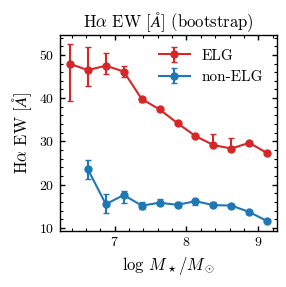

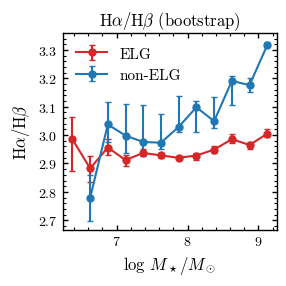

In [13]:
def plot_vs_mstar(results, qname, mode=MODE, use_bootstrap_median=False):
    fig, ax = plt.subplots(figsize=(3, 3))
    for token in SAMPLE_TOKENS:
        d = results[qname][token]
        ykey = "y" if not (mode == "bootstrap" and use_bootstrap_median) else "y"
        ax.errorbar(
            d["x"], d[ykey],
            yerr=[d["yerr_lo"], d["yerr_hi"]],
            fmt="o-", capsize=2, color=d["color"], label=d["label"],
        )
    ax.set_xlabel(r"log $M_\star/M_\odot$")
    ax.set_ylabel(QUANTITY_LABELS[qname])
    ax.legend(frameon=False)
    ax.set_title(f"{QUANTITY_LABELS[qname]} ({mode})")
    fig.tight_layout()
    return fig

for q in ["halpha_ew", "ha_hb"]:
    plot_vs_mstar(results, q)
    plt.show()

In [20]:
stack_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/direct_metallicity_results.fits")


In [31]:
mstar_bin_cens = 0.5*(stack_cat["MSTAR_MIN"] + stack_cat["MSTAR_MAX"])



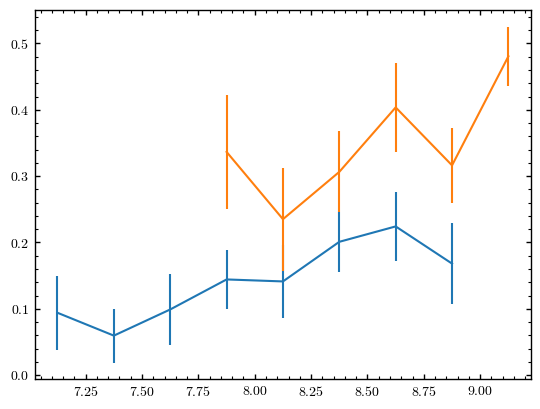

In [41]:

plt.errorbar(mstar_bin_cens[ (stack_cat["EW_TOKEN"] == "elg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ],   y=stack_cat[ (stack_cat["EW_TOKEN"] == "elg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ]["AV"], 
         yerr=stack_cat[(stack_cat["EW_TOKEN"] == "elg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ]["AV_ERR"] )

plt.errorbar(mstar_bin_cens[ (stack_cat["EW_TOKEN"] == "noelg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ],   y=stack_cat[ (stack_cat["EW_TOKEN"] == "noelg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ]["AV"], 
         yerr=stack_cat[ (stack_cat["EW_TOKEN"] == "noelg") & (stack_cat["MEAN_FIT_SUCCESS"] == True) ]["AV_ERR"] )

plt.show()

In [43]:
## generally speaking, show the difference in the stacked spectra between the two!

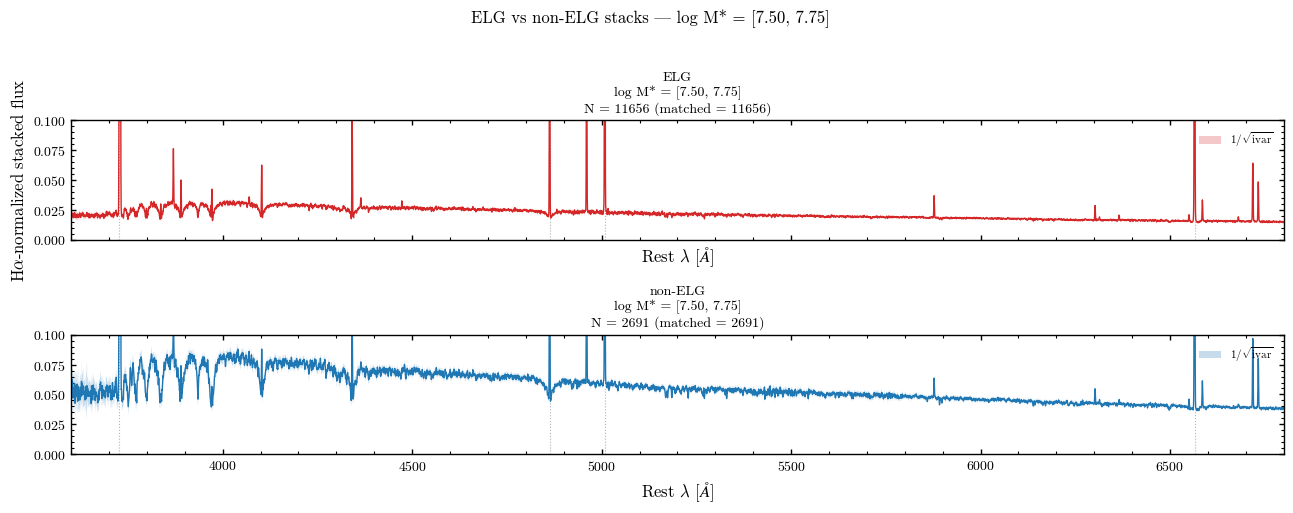

In [51]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

STACK_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"

# mass bin to compare
MLO, MHI = 7.50, 7.75

LINE_GUIDES = {
    3727.0: "[OII]",
    4862.7: r"H$\beta$",
    5008.2: "[OIII]",
    6564.6: r"H$\alpha$",
}


def load_stack_pkl(sample, mlo, mhi, stack_path=STACK_PATH):
    """Load one stacks_spec_*.pkl + wavelength from matching stack FITS."""
    pkl_path = os.path.join(
        stack_path, f"stacks_spec_{sample}_mstar_{mlo:.2f}_{mhi:.2f}.pkl"
    )
    fits_path = os.path.join(
        stack_path, f"stack_mstar_{sample}_{mlo:.2f}_{mhi:.2f}.fits"
    )
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(pkl_path)
    if not os.path.exists(fits_path):
        raise FileNotFoundError(fits_path)

    with open(pkl_path, "rb") as f:
        saved = pickle.load(f)

    with fits.open(fits_path) as hdul:
        wave = hdul["WAVE"].data.astype(float)

    flux = np.asarray(saved["stack_spec"], dtype=float)
    central_ivar = np.asarray(saved["central_ivar"], dtype=float)
    meas_err = np.where(central_ivar > 0, 1.0 / np.sqrt(central_ivar), np.nan)

    label = "ELG" if sample == "elg" else "non-ELG"
    title = (
        f"{label}\n"
        f"log M* = [{saved['mstar_min']:.2f}, {saved['mstar_max']:.2f}]\n"
        f"N = {saved['n_galaxies']} (matched = {saved['n_matched']})"
    )
    return wave, flux, meas_err, title


def plot_elg_vs_noelg(mlo=MLO, mhi=MHI, stack_path=STACK_PATH):
    samples = [
        ("elg", "#d62728"),
        ("noelg", "#1f77b4"),
    ]

    data = {}
    for sample, color in samples:
        wave, flux, meas_err, title = load_stack_pkl(sample, mlo, mhi, stack_path)
        data[sample] = dict(wave=wave, flux=flux, meas_err=meas_err, title=title, color=color)

    # shared limits for fair comparison
    wave = data["elg"]["wave"]
    xlim = (wave.min(), wave.max())
    ymax = max(
        np.nanmax(d["flux"] + d["meas_err"]) for d in data.values()
    )
    ymin = min(
        np.nanmin(d["flux"] - d["meas_err"]) for d in data.values()
    )
    pad = 0.05 * (ymax - ymin)
    ylim = (ymin - pad, ymax + pad)

    fig, axes = plt.subplots(2,1, figsize=(13, 5), sharex=True, sharey=True)

    for ax, (sample, _) in zip(axes, samples):
        d = data[sample]
        ax.plot(d["wave"], d["flux"], color=d["color"], lw=1.0)
        ax.fill_between(
            d["wave"],
            d["flux"] - d["meas_err"],
            d["flux"] + d["meas_err"],
            color=d["color"],
            alpha=0.25,
            lw=0,
            label=r"$1/\sqrt{\mathrm{ivar}}$",
        )
        for lam in LINE_GUIDES:
            ax.axvline(lam, color="grey", ls=":", lw=0.8, alpha=0.6, zorder=0)

        ax.set_xlim(xlim)
        # ax.set_ylim(ylim)
        ax.set_ylim([0,0.1])
        
        ax.set_title(d["title"], fontsize=10)
        ax.set_xlabel(r"Rest $\lambda$ [$\AA$]")
        ax.legend(frameon=False, loc="upper right", fontsize=8)

    axes[0].set_ylabel(r"H$\alpha$-normalized stacked flux")
    fig.suptitle(
        f"ELG vs non-ELG stacks | log M* = [{mlo:.2f}, {mhi:.2f}]",
        fontsize=12,
        y=1.02,
    )
    fig.tight_layout()
    return fig, axes, data


fig, axes, data = plot_elg_vs_noelg(MLO, MHI)

plt.show()

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: divide by zero encountered in true_divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: linewidths is ignored by contourf
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py

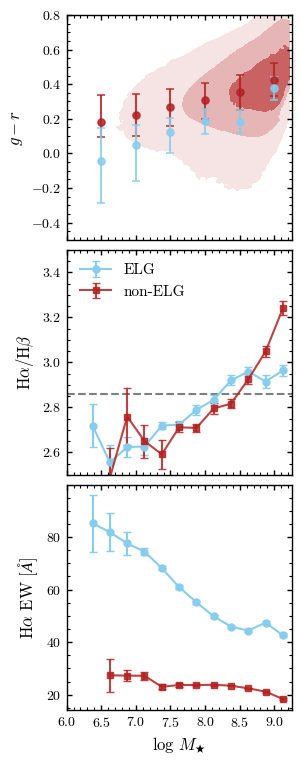

In [25]:
fig, ax = make_subplots(ncol=1, nrow=3, return_fig=True, plot_size = 2.25,
                       row_spacing=[MARGIN_LABEL-0.4, MARGIN_SHARED, MARGIN_SHARED, MARGIN_PAD],
                       col_spacing=[MARGIN_LABEL-0.35, MARGIN_PAD])

#########

plot_2d_dist( tot_cat["LOG_MSTAR_M24"].data[noelg_mask], gr_rest[noelg_mask], 125, 125, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[2], bounds= np.array([ 6,9.25,-0.5,0.8 ]),
            cmap = make_cmap("firebrick"), color = "k", filled=True, label = "BGS Bright",cmap_alpha=1)

bin_width = 0.2
for xcen in np.arange(6,9.25,0.5):
    xdata = tot_cat["LOG_MSTAR_M24"].data[noelg_mask]
    ydata = gr_rest[noelg_mask]

    noelg_color = "firebrick" 
    
    mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
    if mask.sum() > 25:
        med = np.median(ydata[mask])
        p16 = np.percentile(ydata[mask], 16)
        p84 = np.percentile(ydata[mask], 84)

        ax[2].errorbar(xcen, med,
                     yerr=[[med - p16], [p84 - med]],
                     fmt='o', color=noelg_color, markeredgecolor=noelg_color,
                     markeredgewidth=1.2, markersize=5, alpha=0.85,
                     ecolor=noelg_color, elinewidth=1.5, capsize=3, zorder=10)

    elg_color =  sample_colors["ELG"]
    
    xdata = tot_cat["LOG_MSTAR_M24"].data[elg_mask]
    ydata = gr_rest[elg_mask]
    
    mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
    if mask.sum() > 25:
        med = np.median(ydata[mask])
        p16 = np.percentile(ydata[mask], 16)
        p84 = np.percentile(ydata[mask], 84)

        ax[2].errorbar(xcen, med,
                     yerr=[[med - p16], [p84 - med]],
                     fmt='o', color=elg_color, markeredgecolor=elg_color,
                     markeredgewidth=1.2, markersize=5, alpha=0.85,
                     ecolor=elg_color, elinewidth=1.5, capsize=3, zorder=10)

ax[2].set_ylim([-0.5,0.8])

#########

plot_config = [
    (ax[0], "halpha_ew",    r"H$\alpha$ EW [$\AA$]"),
    (ax[1], "ha_hb",        r"H$\alpha$/H$\beta$"),
]
 
for axi, qname, ylabel in plot_config:
    axi.errorbar(mstar_cens, mstar_data[qname]["elg"],
                 yerr=mstar_data[qname]["elg_err"],
                 fmt="o-", capsize=3,
                 color=sample_colors["ELG"], label="ELG")
    axi.errorbar(mstar_cens, mstar_data[qname]["noelg"],
                 yerr=mstar_data[qname]["noelg_err"],
                 fmt="s-", capsize=3, alpha=0.85,
                 color="firebrick", label="non-ELG")
    axi.set_ylabel(ylabel)
 
# Balmer-decrement Case-B reference (T = 1e4 K)
ax[1].axhline(2.86, color="k", ls="--", alpha=0.5, lw=1.5, zorder=0)

ax[1].set_ylim([2.5,3.5])

ax[0].set_xlabel(r"log $M_{\bigstar}$")

ax[2].set_ylabel(r"$g-r$")

ax[1].legend(frameon=False)

for i in range(3):
    ax[i].set_xticks([6,6.5,7, 7.5, 8, 8.5, 9])
    ax[i].set_xlim(6, 9.25)

ax[1].set_xticklabels([])
ax[2].set_xticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/elg_vs_not_elg.pdf")

plt.show()
 

In [14]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")


In [23]:
# fig,ax = make_subplots(ncol = 1, nrow = 1, return_fig=True)

# # norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=zred_cens.max())
# norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=0.35)
# # norm = mcolors.Normalize(vmin=0.0375, vmax=0.4)

# cmap = cmr.arctic  # or viridis, coolwarm, etc.

# # scatter points colored by redshift
# sc = ax[0].scatter(gr_obs_elg, rz_obs_elg, c=zred_cens, cmap=cmap, norm=norm,
#                    edgecolors='k', linewidths=0.5, s=50, zorder=3)

# # optionally color the line segments too
# for i in range(len(gr_elg)-1):
#     ax[0].plot(gr_obs_elg[i:i+2], rz_obs_elg[i:i+2],
#                color=cmap(norm(zred_cens[i])), zorder=2)

# # inset colorbar
# cbax = ax[0].inset_axes([0.075, 0.91, 0.35, 0.02])  # wide & short for horizontal
# cbar = plt.colorbar(sc, cax=cbax, orientation='horizontal')
# cbar.set_label(r"$z$", fontsize=13, labelpad=5)  # negative pad puts label on top
# cbar.ax.tick_params(labelsize=10, bottom=True, top=False)
# cbar.ax.set_xticks([0.1,0.2,0.3])
# cbar.ax.xaxis.set_label_position('top')

# ####


# ellipse_bins = [3]

# for i in ellipse_bins:
#     w, h, angle = ellipse_obs_elg[i]
#     if np.isfinite(w):
#         ellipse = Ellipse((gr_obs_elg[i], rz_obs_elg[i]), width=w, height=h, angle=angle,
#                   facecolor='none', edgecolor=cmap(norm(zred_cens[i])), linewidth=1.5, zorder=5, ls="dotted", alpha=0.7)
#         ax[0].add_patch(ellipse)
    

# nonelg_color = "firebrick"

# plot_2d_dist(tot_cat_no_elg["g-r"], tot_cat_no_elg["r-z"], 150, 150, 
#                 cmin=1.e-4, cmax=1.0, smooth=None, clevs=[0,0.393,0.865,0.989],ax=ax[0], bounds= np.array([ -1,1,-1,1]),
#             cmap = make_cmap("firebrick"), color = nonelg_color, filled=True, cmap_alpha=1)

# start = 0.175

# ax[0].text(0.14,0.6,"ELG",color = "tab:blue", transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center",alpha=1 )

# ax[0].text(0.75,0.17,"non-ELG",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center" )

# zred_med_noelg = np.median(tot_cat_no_elg["Z"])

# ax[0].text(0.75,0.1,rf"$(z_{{\rm med}} \sim {zred_med_noelg:.3f})$",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 13,ha="center",va="center" )


# ax[0].set_xlim([0,0.8])
# ax[0].set_ylim([0,0.7])

# ax[0].set_xlabel(r"$(g-r)_{0}$",fontsize=17)
# ax[0].set_ylabel(r"$(r-z)_{0}$",fontsize=17)

# # ax[0].set_xticks([0,0.25,0.5,0.75])
# # ax[0].set_yticks([0,0.25,0.5,0.75])

# ###plot the ELG color selection:

# gr_elg_box = [-0.5039115756670784, 0.17415113938843074, 0.5343050055184053, -0.5072323573329873 ]
# rz_elg_box = [0.13744075829383862, 0.14691943127962093, 0.8720379146919433, 1.753554502369668 ]

# ax[0].plot(gr_elg_box, rz_elg_box,color="k",ls="dotted")

# # from matplotlib.patches import Polygon

# # # Define vertices that enclose the region above/left of the color box
# # # Go along the box boundary, then extend to the plot corners
# # shade_verts = [
# #     (gr_elg_box[0], rz_elg_box[0]),  # bottom-left of box
# #     (gr_elg_box[1], rz_elg_box[1]),  # bottom-right of box
# #     (gr_elg_box[2], rz_elg_box[2]),  # top-right of box
# #     (gr_elg_box[3], rz_elg_box[3]),  # top-left of box
# #     # now extend to plot corners (upper-left region)
# #     (ax[0].get_xlim()[0], ax[0].get_ylim()[1]),  # top-left corner
# #     (ax[0].get_xlim()[0], rz_elg_box[0]),         # back to left edge at box height
# # ]

# # shade = Polygon(shade_verts, closed=True, facecolor='dodgerblue', alpha=0.15, edgecolor='none', zorder=0)
# # ax[0].add_patch(shade)

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_gr_rz_plot.pdf",bbox_inches="tight")

# plt.show()